# Part 1 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Part 2 — Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Part 3 — Create Score Categories

In [6]:
def score_category(score):

    if score < 65:
        return "Low"

    elif score < 80:
        return "Medium"

    else:
        return "High"


df['Score_Category'] = df['Exam_Score'].apply(score_category)

df[['Exam_Score', 'Score_Category']].head()

,Exam_Score,Score_Category
0,67,Medium
1,61,Low
2,74,Medium
3,71,Medium
4,70,Medium


# Part 4 — Class Distribution

In [7]:
print(df['Score_Category'].value_counts())

Score_Category
Medium    5107
Low       1452
High        48
Name: count, dtype: int64


# Part 4B — Visualize Class Distribution

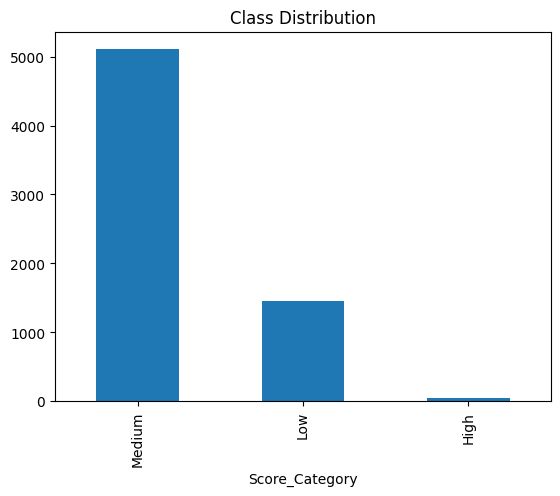

In [8]:
df['Score_Category'].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.show()

# Part 5 — Features and Target

In [9]:
X = df.drop(columns=['Exam_Score', 'Score_Category'])

y = df['Score_Category']

print(X.head())

print(y.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

# Part 6 — Handle Missing Values

In [10]:
X['Teacher_Quality'] = X['Teacher_Quality'].fillna(
    X['Teacher_Quality'].mode()[0]
)

X['Parental_Education_Level'] = X['Parental_Education_Level'].fillna(
    X['Parental_Education_Level'].mode()[0]
)

X['Distance_from_Home'] = X['Distance_from_Home'].fillna(
    X['Distance_from_Home'].mode()[0]
)

print(X.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
dtype: int64


# Part 7 — Define Columns

In [12]:
ordinal_cols = [
    'Parental_Involvement',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality'
]

nominal_cols = [
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Internet_Access',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Parental_Education_Level',
    'Distance_from_Home',
    'Gender'
]

numeric_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]

# Part 8 — Preprocessing

In [13]:
mapping_order = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High']
]

preprocessor = ColumnTransformer(
    transformers=[

        (
            'ord',
            OrdinalEncoder(categories=mapping_order),
            ordinal_cols
        ),

        (
            'nom',
            OneHotEncoder(drop='first', sparse_output=False),
            nominal_cols
        ),

        (
            'num',
            StandardScaler(),
            numeric_cols
        )
    ]
)

print("Preprocessor Ready")

Preprocessor Ready


# Part 9 — Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5285, 19)
(1322, 19)


# Part 10 — Transform Data

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(5285, 23)
(1322, 23)


# Part 11 — Train Model

In [16]:
nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train)

print("Model Trained")

Model Trained


# Part 12 — Predictions

In [17]:
y_pred = nb_model.predict(X_test_processed)

print(y_pred[:10])

['Low' 'Medium' 'Medium' 'Low' 'Medium' 'Low' 'Medium' 'Medium' 'Low'
 'Low']


# Part 13 — Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8964


# Part 14 — Classification Report

In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        10
         Low       0.89      0.63      0.74       290
      Medium       0.90      0.98      0.94      1022

    accuracy                           0.90      1322
   macro avg       0.60      0.54      0.56      1322
weighted avg       0.89      0.90      0.89      1322



# Part 15 — Confusion Matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   0    1    9]
 [   0  184  106]
 [   0   21 1001]]


# Part 16 — Plot Confusion Matrix

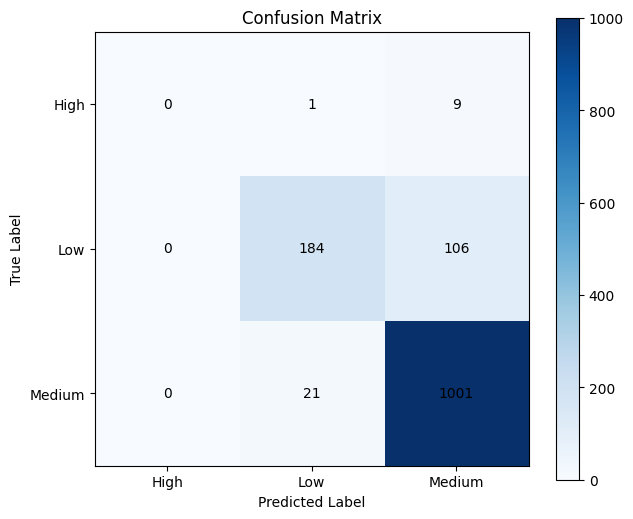

In [21]:
plt.figure(figsize=(7, 6))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.colorbar()

classes = ['High', 'Low', 'Medium']

plt.xticks(np.arange(len(classes)), classes)

plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()